# 🔢 실습 — 텍스트를 숫자로 바꾸기 (학생용)

Counter, CountVectorizer, TF-IDF, n-gram을 직접 코드로 실습합니다.

> **🖥️ 환경 설정**
> - 로컬 `UD_26` 실행: `uv run jupyter lab`
> - 로컬 `UD_26` 패키지 에러: `uv add scikit-learn pandas matplotlib koreanize-matplotlib`
> - Colab 패키지 에러: `!pip install scikit-learn pandas matplotlib koreanize-matplotlib -q`

> **⌨️ 단축키 안내**
> | 단축키 | 동작 |
> |--------|------|
> | `Shift + Enter` | 셀 실행 후 다음 셀 이동 |
> | `Esc → A` | 위에 셀 삽입 |
> | `Esc → B` | 아래에 셀 삽입 |
> | `Esc → DD` | 셀 삭제 |

In [1]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

## 📌 §210 빈도는 중요도가 아니다

단순 빈도 카운팅의 한계를 직접 확인합니다. 모든 문서에 등장하는 단어가 가장 높은 빈도를 차지하는 문제를 봅니다.

[→ §210 강의노트](../notes/UD-05-210__text-to-number-matrix.md)

In [4]:
# 📌 §210 ⚠️ 나쁜 결과를 먼저 보자
corpus = [
    "코로나 거리두기와 코로나 상생지원금 문의입니다.",
    "지하철 운행시간과 지하철 요금 문의입니다.",
    "지하철 승강장 문의입니다.",
    "택시 승강장 문의입니다."
]

# 코드를 작성해주세요 👇
# 공백 기준 분리 → Counter
all_words = []
for doc in corpus:
	all_words.extend(doc.split())

counter = Counter(all_words)
print(counter.most_common(5))

# 예상 출력: [('문의입니다.', 4), ('지하철', 3), ('코로나', 2), ('승강장', 2), ...]

[('문의입니다.', 4), ('지하철', 3), ('코로나', 2), ('승강장', 2), ('거리두기와', 1)]


## 📌 §210 텍스트를 숫자 행렬로

CountVectorizer로 텍스트를 문서-단어 행렬(DTM)로 변환하는 3단계를 실습합니다.

[→ §210 강의노트](../notes/UD-05-210__text-to-number-matrix.md)

🔗 [scikit-learn CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)

In [5]:
# 📌 §210 Step 1: fit(어휘 학습)
# 코드를 작성해주세요 👇
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
	"코로나 거리두기와 코로나 상생지원금 문의입니다.",
	"지하철 운행시간과 지하철 요금 문의입니다.",
	"지하철 승강장 문의입니다.",
	"택시 승강장 문의입니다."
]

cvect = CountVectorizer()
cvect.fit(corpus)  # 어휘 사전 학습

print(cvect.vocabulary_)

# 예상 출력: {'코로나': 7, '거리두기와': 0, '상생지원금': 2, '문의입니다': 1, ...}

{'코로나': 7, '거리두기와': 0, '상생지원금': 2, '문의입니다': 1, '지하철': 6, '운행시간과': 5, '요금': 4, '승강장': 3, '택시': 8}


In [6]:
# 📌 §210 Step 2: transform(행렬 변환)
# 코드를 작성해주세요 👇
dtm = cvect.transform(corpus)
print(dtm)

# 예상 출력: <4x9 sparse matrix of type '<class 'numpy.int64'>'>

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 14 stored elements and shape (4, 9)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 7)	2
  (1, 1)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	2
  (2, 1)	1
  (2, 3)	1
  (2, 6)	1
  (3, 1)	1
  (3, 3)	1
  (3, 8)	1


In [7]:
# 📌 §210 Step 3: DataFrame으로 확인
# 코드를 작성해주세요 👇
import pandas as pd

vocab = cvect.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
print(df_dtm)

# 예상 출력:
#    거리두기와  문의입니다  상생지원금  승강장  요금  운행시간과  지하철  코로나  택시
# 0      1      1      1    0   0      0    0    2   0
# 1      0      1      0    0   1      1    2    0   0
# 2      0      1      0    1   0      0    1    0   0
# 3      0      1      0    1   0      0    0    0   1

   거리두기와  문의입니다  상생지원금  승강장  요금  운행시간과  지하철  코로나  택시
0      1      1      1    0   0      0    0    2   0
1      0      1      0    0   1      1    2    0   0
2      0      1      0    1   0      0    1    0   0
3      0      1      0    1   0      0    0    0   1


In [8]:
# 📌 §210 fit_transform
# 코드를 작성해주세요 👇
dtm = cvect.fit_transform(corpus)
# fit() + transform()을 동시에 수행

# 예상 출력: (출력 없음 — dtm 변수에 저장됨)

In [9]:
# 📌 §210 단어 빈도 합계
# 코드를 작성해주세요 👇
df_dtm.sum().to_frame().T

# 예상 출력:
#    거리두기와  문의입니다  상생지원금  승강장  요금  운행시간과  지하철  코로나  택시
# 0      1      4      1    2   1      1    3    2   1

,거리두기와,문의입니다,상생지원금,승강장,요금,운행시간과,지하철,코로나,택시
0,1,4,1,2,1,1,3,2,1


## 📌 §220 TF-IDF 가중치

TfidfVectorizer로 단순 빈도 대신 중요도 가중치를 부여합니다. IDF가 낮은 단어는 변별력이 없음을 확인합니다.

[→ §220 강의노트](../notes/UD-05-220__tfidf-weighting.md)

🔗 [scikit-learn TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [10]:
# 📌 §220 TfidfVectorizer 코드
# 코드를 작성해주세요 👇
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
	"코로나 거리두기와 코로나 상생지원금 문의입니다.",
	"지하철 운행시간과 지하철 요금 문의입니다.",
	"지하철 승강장 문의입니다.",
	"택시 승강장 문의입니다."
]

tfidfvect = TfidfVectorizer()
dtm = tfidfvect.fit_transform(corpus)

vocab = tfidfvect.get_feature_names_out()
df_tfidf = pd.DataFrame(dtm.toarray(), columns=vocab)
print(df_tfidf.round(3))

# 예상 출력:
#    거리두기와  문의입니다  상생지원금  승강장   요금  운행시간과  지하철  코로나   택시
# 0    0.399    0.208    0.399  0.000  0.000    0.000  0.000  0.799  0.000
# 1    0.000    0.239    0.000  0.000  0.458    0.458  0.723  0.000  0.000
# 2    0.000    0.424    0.000  0.640  0.000    0.000  0.640  0.000  0.000
# 3    0.000    0.379    0.000  0.573  0.000    0.000  0.000  0.000  0.727

   거리두기와  문의입니다  상생지원금    승강장     요금  운행시간과    지하철    코로나     택시
0  0.399  0.208  0.399  0.000  0.000  0.000  0.000  0.799  0.000
1  0.000  0.239  0.000  0.000  0.458  0.458  0.723  0.000  0.000
2  0.000  0.424  0.000  0.640  0.000  0.000  0.640  0.000  0.000
3  0.000  0.379  0.000  0.573  0.000  0.000  0.000  0.000  0.727


문의입니다    1.000000
승강장      1.510826
지하철      1.510826
거리두기와    1.916291
상생지원금    1.916291
요금       1.916291
운행시간과    1.916291
코로나      1.916291
택시       1.916291
dtype: float64


<Axes: title={'center': 'IDF 값 비교'}>

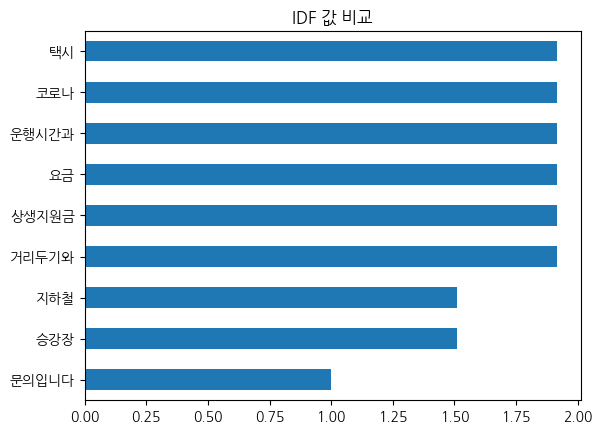

In [12]:
# 📌 §220 IDF 값 확인
import matplotlib.pyplot as plt
import koreanize_matplotlib
import pandas as pd

# 코드를 작성해주세요 👇
idf = tfidfvect.idf_
vocab = tfidfvect.get_feature_names_out()

idf_series = pd.Series(dict(zip(vocab, idf)))
print(idf_series.sort_values())

# 예상 출력:
# 문의입니다    1.000
# 승강장       1.511
# 지하철       1.511
# 거리두기와    1.916
# ...

# IDF 막대 그래프도 그려보세요
idf_series.sort_values().plot.barh(title="IDF 값 비교")
# 예상 출력: IDF 막대 그래프 (문의입니다가 가장 낮음)

## 📌 §230 n-gram과 노이즈 제어

BoW의 순서 무시 문제를 확인하고, n-gram과 파라미터 조합으로 노이즈를 제어하는 방법을 실습합니다.

[→ §230 강의노트](../notes/UD-05-230__ngram-and-noise-control.md)

In [13]:
# 📌 §230 BoW 순서 무시 예시
doc_a = "맛있는 음식"
doc_b = "음식 맛있는"

# CountVectorizer로 변환하면?
# doc_a: {'맛있는': 1, '음식': 1}
# doc_b: {'맛있는': 1, '음식': 1}
# → 완전히 같은 결과!
# 예상 출력: (출력 없음 — 주석으로 확인)

In [14]:
# 📌 §230 ngram_range 비교
# 코드를 작성해주세요 👇
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
	"코로나 거리두기와 코로나 상생지원금 문의입니다.",
	"지하철 운행시간과 지하철 요금 문의입니다.",
	"지하철 승강장 문의입니다.",
	"택시 승강장 문의입니다."
]

# uni-gram만 (기본값)
cvect_uni = CountVectorizer(ngram_range=(1, 1))
dtm_uni = cvect_uni.fit_transform(corpus)
print(f"(1,1) 단어 수: {dtm_uni.shape[1]}")
# 예상 출력: (1,1) 단어 수: 9

# uni-gram + bi-gram
cvect_bi = CountVectorizer(ngram_range=(1, 2))
dtm_bi = cvect_bi.fit_transform(corpus)
print(f"(1,2) 단어 수: {dtm_bi.shape[1]}")

# 예상 출력: (1,1) 단어 수: 9
# 예상 출력: (1,2) 단어 수: 20

(1,1) 단어 수: 9
(1,2) 단어 수: 20


In [15]:
# 📌 §230 실전 파라미터 조합
# 코드를 작성해주세요 👇
cvect = CountVectorizer(
	ngram_range=(1, 2),
	min_df=2,        # 2번 이상 등장한 단어만
	max_df=0.9,      # 90% 이상 문서에 등장하면 제외
	max_features=100  # 최대 100개 단어
)

import pandas as pd

dtm = cvect.fit_transform(corpus)

print("DTM shape:", dtm.shape)
print("선택된 feature 수:", len(cvect.get_feature_names_out()))
print("선택된 feature:")
print(cvect.get_feature_names_out())

df_dtm = pd.DataFrame(
	dtm.toarray(),
	columns=cvect.get_feature_names_out()
)
print(df_dtm)

# 예상 출력: (출력 없음 — 파라미터 설정 확인용)

DTM shape: (4, 3)
선택된 feature 수: 3
선택된 feature:
['승강장' '승강장 문의입니다' '지하철']
   승강장  승강장 문의입니다  지하철
0    0          0    0
1    0          0    2
2    1          1    1
3    1          1    0


In [ ]:
# 📌 §230 파라미터 적용 결과 확인
# 코드를 작성해주세요 👇

# 힌트:
# 1. cvect.fit_transform(corpus)로 DTM을 만드세요.
# 2. cvect.get_feature_names_out()으로 선택된 feature를 확인하세요.
# 3. pd.DataFrame(...)으로 결과 표를 만들어 보세요.

# 예상 출력(정확한 열 이름은 corpus에 따라 달라질 수 있음):
# DTM shape: (4, n)
# 선택된 feature 수: n
# 선택된 feature:
# ['문의입니다' '승강장' '지하철' ...]
